In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

 #1 setup global + fungsi custom
df = sns.load_dataset('tips')

sns.set_theme(style='whitegrid', palette='Set2')

def rapikan_grafik(ax, judul, xlabel, ylabel):
    ax.set_title(judul, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel(xlabel, fontsize=11, labelpad=10)
    ax.set_ylabel(ylabel, fontsize=11, labelpad=10)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()

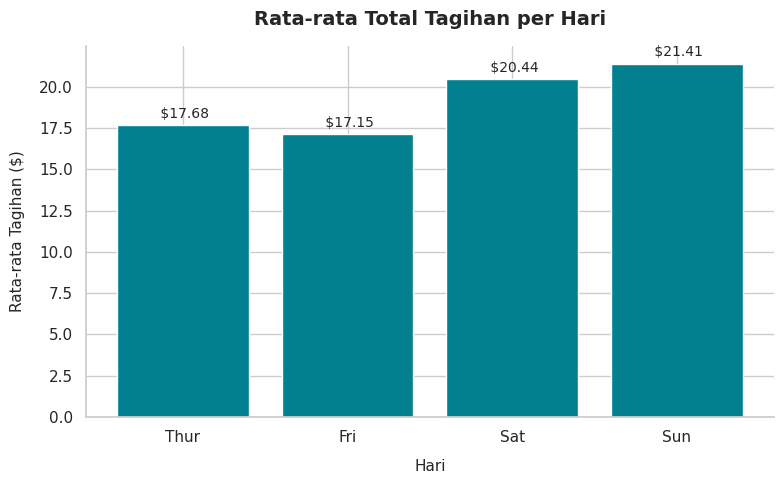

In [2]:
#2 perbandingna kategori dengan bar chart
fig, ax = plt.subplots(figsize=(8, 5))

avg_by_day = df.groupby('day', observed=False)['total_bill'].mean().reset_index()

bars = ax.bar(avg_by_day['day'], avg_by_day['total_bill'], color='#028090', edgecolor='white')

ax.bar_label(bars, fmt=' $%.2f', padding=3, fontsize=10)

rapikan_grafik(ax, 'Rata-rata Total Tagihan per Hari', 'Hari', 'Rata-rata Tagihan ($)')
plt.show()

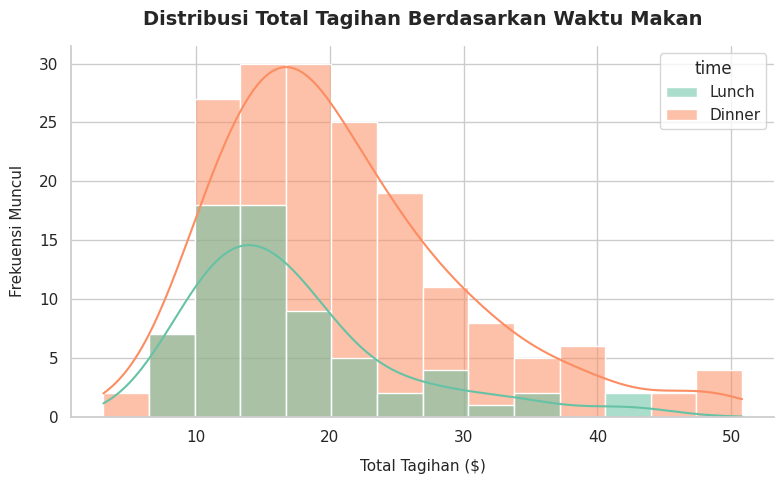

In [3]:
#3 distribusi (histogram + KDE)
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(data=df, x='total_bill', hue='time', kde=True, multiple='layer', alpha=0.55, ax=ax)

rapikan_grafik(ax, 'Distribusi Total Tagihan Berdasarkan Waktu Makan', 'Total Tagihan ($)', 'Frekuensi Muncul')
plt.show()

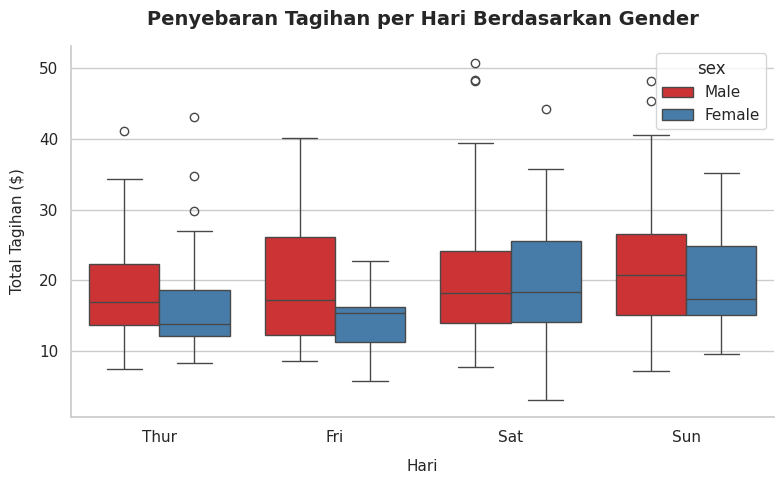

In [4]:
#4 distribusi kelompok
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=df, x='day', y='total_bill', hue='sex', palette='Set1', ax=ax)

rapikan_grafik(ax, 'Penyebaran Tagihan per Hari Berdasarkan Gender', 'Hari', 'Total Tagihan ($)')
plt.show()

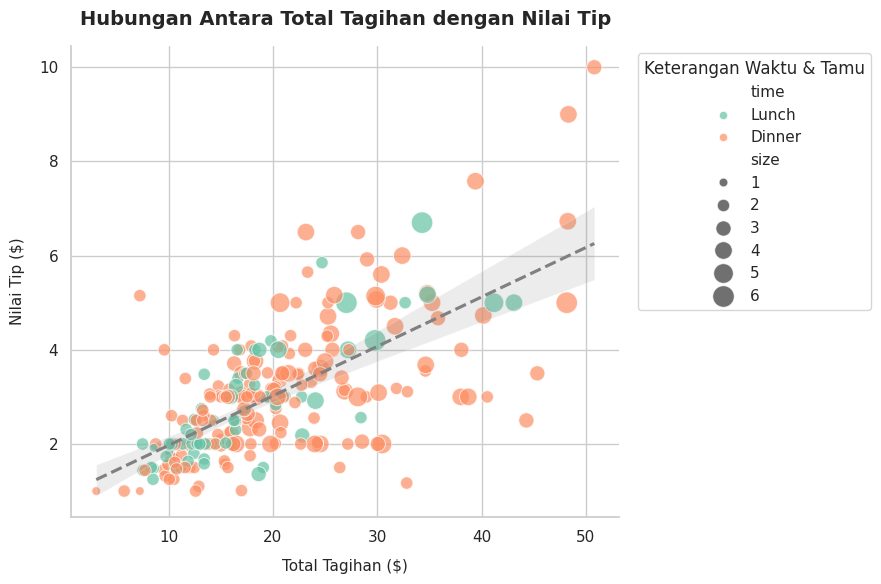

In [5]:
#5 hubungan variabel
fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(data=df, x='total_bill', y='tip', hue='time', size='size', sizes=(40, 240), alpha=0.7, ax=ax)

sns.regplot(data=df, x='total_bill', y='tip', scatter=False, color='gray', line_kws={'linestyle':'--'}, ax=ax)

ax.legend(title='Keterangan Waktu & Tamu', bbox_to_anchor=(1.02, 1), loc='upper left')

rapikan_grafik(ax, 'Hubungan Antara Total Tagihan dengan Nilai Tip', 'Total Tagihan ($)', 'Nilai Tip ($)')
plt.show()